# Superstore Sales Data Analysis (Python Project)

# Objective:
# To analyze sales and profit data across regions, categories, and time to identify key revenue drivers, loss-making areas, and actionable business insights for improving profitability.

## Import Libraries

In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn  as sns

import warnings       # help to remove warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [26]:
df = pd.read_csv("sales_analysis.csv",encoding='latin-1')

In [3]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Month No.,Product name2
0,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017,Nov,11,Bush Somerset Collec
1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017,Nov,11,Hon Deluxe Fabric Up
2,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017,Jun,6,Self-Adhesive Addres
3,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016,Oct,10,Bretford CR4500 Seri
4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016,Oct,10,Eldon Fold 'N Roll C


## Data Understanding

In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9986 entries, 0 to 9985
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9986 non-null   object 
 1   Order Date     9986 non-null   object 
 2   Ship Date      9986 non-null   object 
 3   Ship Mode      9986 non-null   object 
 4   Customer ID    9986 non-null   object 
 5   Customer Name  9986 non-null   object 
 6   Segment        9986 non-null   object 
 7   Country        9986 non-null   object 
 8   City           9986 non-null   object 
 9   State          9986 non-null   object 
 10  Postal Code    9986 non-null   object 
 11  Region         9986 non-null   object 
 12  Product ID     9986 non-null   object 
 13  Category       9986 non-null   object 
 14  Sub-Category   9986 non-null   object 
 15  Product Name   9986 non-null   object 
 16  Sales          9986 non-null   float64
 17  Quantity       9986 non-null   int64  
 18  Discount

,Sales,Quantity,Discount,Profit,Order Year,Month No.
count,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000
mean,229.872779,3.789305,0.156258,28.641480,2016.722111,7.809734
std,623.477775,2.225286,0.206499,234.349134,1.123690,3.284453
min,0.444000,1.000000,0.000000,-6599.978000,2015.000000,1.000000
25%,17.248000,2.000000,0.000000,1.728000,2016.000000,5.000000
50%,54.384000,3.000000,0.200000,8.641350,2017.000000,9.000000
75%,209.917500,5.000000,0.200000,29.353800,2018.000000,11.000000
max,22638.480000,14.000000,0.800000,8399.976000,2018.000000,12.000000


## Data Cleaning

In [5]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order Year       0
Order Month      0
Month No.        0
Product name2    0
dtype: int64

In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# No major missing values or duplicates found.

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True,errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True,errors='coerce')

In [9]:
df['Order Date'].isna().sum()
df['Ship Date'].isna().sum()

0

In [10]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [11]:
df.dtypes

Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Year                int64
Order Month              object
Month No.                 int64
Product name2            object
dtype: object

In [12]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [13]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Month No.,Product name2,Profit Margin
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017,Nov,11,Bush Somerset Collec,0.1600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017,Nov,11,Hon Deluxe Fabric Up,0.3000
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017,Jun,6,Self-Adhesive Addres,0.4700
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016,Oct,10,Bretford CR4500 Seri,-0.4000
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016,Oct,10,Eldon Fold 'N Roll C,0.1125


In [14]:
df['Sales'].sort_values(ascending=False).head()

2694    22638.480
6820    17499.950
8146    13999.960
2620    11199.968
4185    10499.970
Name: Sales, dtype: float64

In [15]:
df['Profit'].sort_values().head()

7766   -6599.9780
681    -3839.9904
9766   -3701.8928
3008   -3399.9800
4986   -2929.4845
Name: Profit, dtype: float64

In [16]:
df['Sales'].sum()

2295509.5723

In [17]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       677906.3680
South      391007.8250
West       725355.4885
Name: Sales, dtype: float64

In [18]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18380.2814
Office Supplies    122247.4038
Technology         145386.1344
Name: Profit, dtype: float64

In [19]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

## Key Performance Indicators (KPIs)

In [27]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df.shape[0]
avg_profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Profit Margin: {avg_profit_margin:.2f}%")

Total Sales: 2,295,509.57
Total Profit: 286,013.82
Total Orders: 9986
Average Profit Margin: 12.46%


# Insight:
# The business generated strong overall sales, but the profit margin indicates room for improvement, suggesting that costs or discounts may be impacting profitability.

## Exploratory Data Analysis

# 1. Loss Analysis

<Axes: xlabel='Category'>

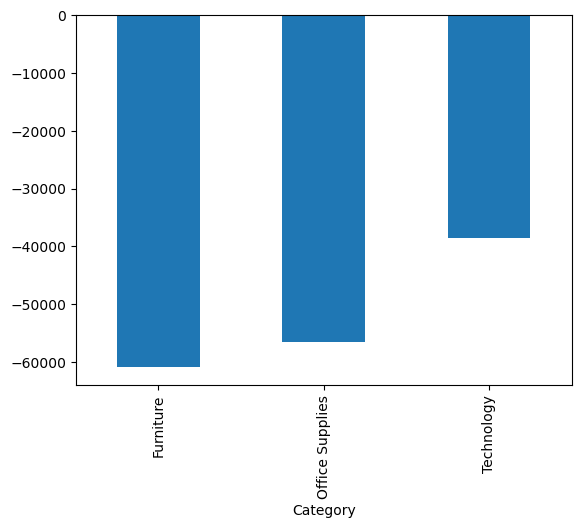

In [21]:
loss_df = df[df['Profit'] < 0]
loss_df.groupby('Category')['Profit'].sum().plot(kind='bar')

# Insight:
# The Furniture category contributes the highest losses among all categories, indicating significant inefficiencies in pricing, discounting, or cost structure. Despite generating sales, the negative profit suggests that high discounts or operational costs (such as shipping or storage) are eroding margins. This highlights the need to reassess pricing strategies and control discount levels in this category.

# 2. Top 10 Products by Sales

<Axes: ylabel='Product name2'>

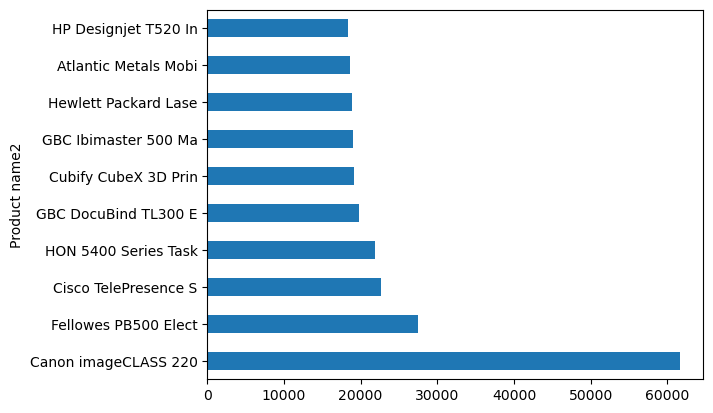

In [22]:
top_products = df.groupby('Product name2')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh')

# Insight:
# A small group of products contributes a disproportionately high share of total revenue, indicating a strong dependency on top-performing products. These high-selling products act as key revenue drivers for the business. However, high sales do not necessarily guarantee high profitability, so further analysis is required to evaluate their profit margins. These products present opportunities for targeted marketing, bundling, and inventory prioritization.

# 3. Sales Over Time

<Axes: xlabel='Order Date'>

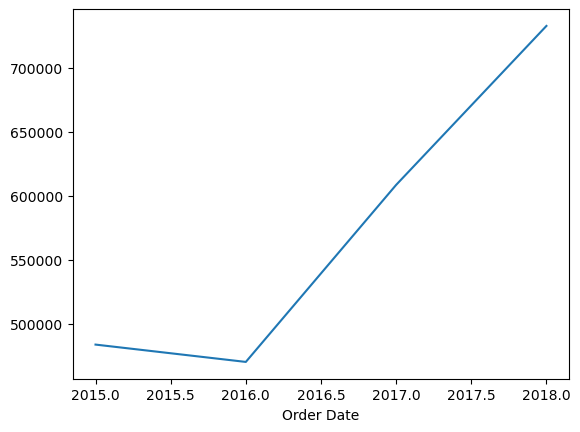

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.groupby(df['Order Date'].dt.year)['Sales'].sum().plot()

# Insight:
# Sales exhibit a clear upward trend over time, indicating overall business growth and increasing demand. However, fluctuations between years suggest potential seasonality or inconsistent performance across periods. The strong growth in later years reflects improved market reach or business expansion, but further analysis is needed to ensure that this growth is sustainable and not driven by excessive discounting or reduced profit margins.

# 4. Correlation Heatmap

<Axes: >

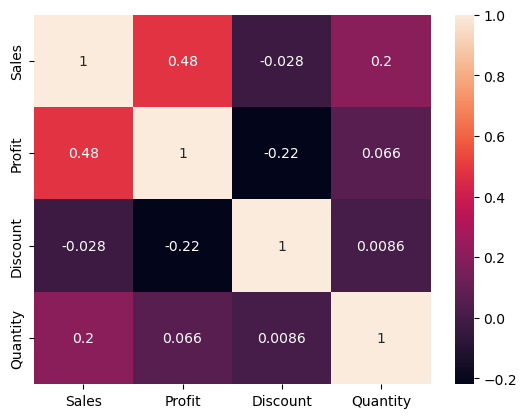

In [24]:
import seaborn as sns
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)

# Insight:
# The correlation analysis reveals a moderate positive relationship between sales and profit, indicating that higher sales generally contribute to higher profits. However, discount shows a negative correlation with profit, suggesting that increased discounting reduces profitability. This highlights a critical trade-off between boosting sales through discounts and maintaining profit margins. The weak correlation between quantity and profit further suggests that simply increasing order volume does not significantly improve profitability.

# 5. Discount vs Profit

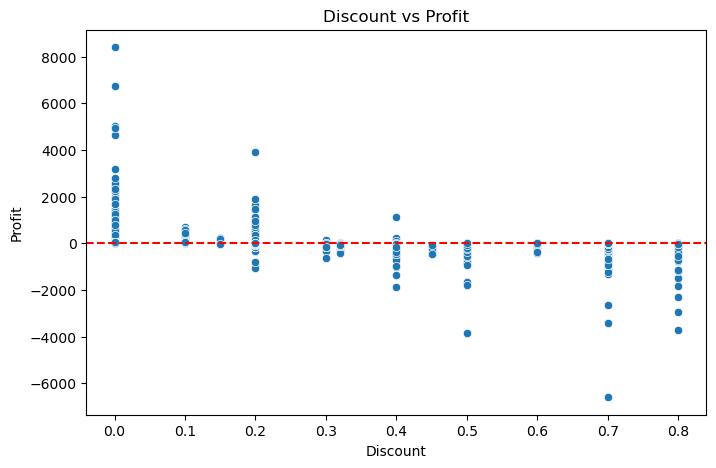

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0, color='red', linestyle='--')  # profit = 0 line

# Insight:
# The scatter plot shows a clear negative relationship between discount and profit, where higher discount levels are frequently associated with lower or negative profits. A significant number of transactions with high discounts fall below the zero-profit line, indicating losses. This suggests that aggressive discounting is a major factor driving unprofitable sales, and optimizing discount strategies could significantly improve overall profitability.

# 6. Profit Margin by Category

Text(0, 0.5, 'Profit Margin')

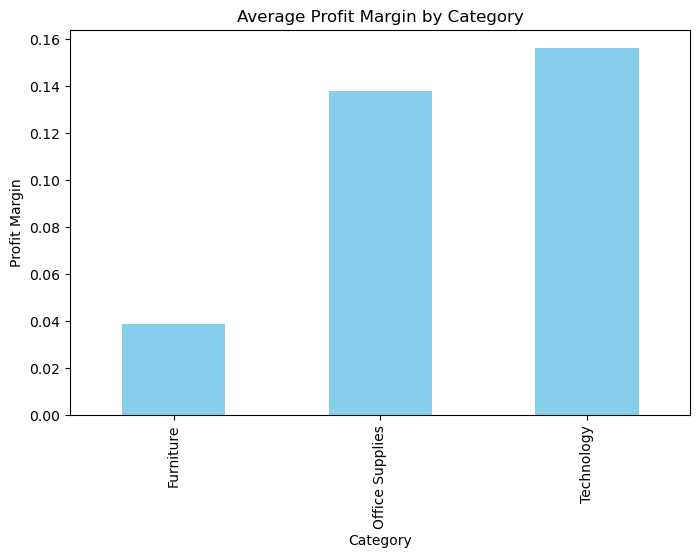

In [31]:
df['Profit Margin'] = df['Profit'] / df['Sales']
category_margin = df.groupby('Category')['Profit Margin'].mean().sort_values()

plt.figure(figsize=(8,5))
category_margin.plot(kind='bar', color='skyblue')
plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")

# Insight:
# The analysis of average profit margin across categories reveals that not all high-revenue categories are equally profitable. While some categories maintain healthy margins, others—particularly Furniture—show significantly lower or even negative margins. This indicates inefficiencies in pricing or cost management and highlights the need to focus on improving margins rather than just increasing sales volume.

# Conclusion

## The analysis of the Superstore sales data reveals that the business is experiencing steady growth in sales over time, indicating increasing demand and expansion. However, this growth is not fully translating into profitability.

## Certain categories, particularly Furniture, contribute significantly to overall losses despite generating revenue. Additionally, the analysis shows that higher discount levels are negatively impacting profit margins, leading to unprofitable transactions.

## The business also relies heavily on a small group of top-performing products for revenue generation, which creates dependency risks. While these products drive sales, their profitability needs to be carefully monitored.

## Overall, the findings highlight that while the company is successful in generating sales, there is a strong need to optimize pricing strategies, control discounts, and focus on profitability to ensure sustainable growth.

# Recommendations

## - Optimize Discount Strategy: Reduce excessive discounting, especially on low-margin products, to prevent negative profits.

## - Improve Furniture Category Performance: Re-evaluate pricing, supply chain costs, and discount policies in the Furniture category to reduce losses.

## - Focus on High-Margin Products: Identify and promote products with higher profit margins to improve overall profitability.

## - Monitor Top-Selling Products: While top products drive revenue, regularly analyze their profit margins to ensure they are not contributing to hidden losses.

## - Expand High-Performing Regions: Invest more in regions with strong sales and profitability to maximize returns.

## - Data-Driven Decision Making: Continuously use data analysis to track performance trends and make informed business decisions.